# 판다스

### 1. 판다스 사용 준비

In [1]:
import pandas as pd
pd.__version__

'2.3.3'

### 2. 시리즈 객체의 생성

In [2]:
numbers = [1, 2, 3, 4, 5]
list_sr = pd.Series(numbers)
print(list_sr)
type(list_sr)

0    1
1    2
2    3
3    4
4    5
dtype: int64


pandas.core.series.Series

In [3]:
print(list_sr.dtype, list_sr.shape, list_sr.size, list_sr.name)

int64 (5,) 5 None


In [4]:
dict_data = {'a':1, 'b':2, 'c':3, 'd':4, 'e':5}
dict_sr = pd.Series(dict_data)
print(dict_sr)
print(dict_sr.dtype, dict_sr.shape, dict_sr.size, dict_sr.name)

a    1
b    2
c    3
d    4
e    5
dtype: int64
int64 (5,) 5 None


In [5]:
list_sr.name = 'mySeries'
list_sr

0    1
1    2
2    3
3    4
4    5
Name: mySeries, dtype: int64

In [6]:
list_sr.name

'mySeries'

In [7]:
import numpy as np
sr1 = pd.Series(numbers, dtype=np.float32)
sr1

0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
dtype: float32

In [8]:
chars = 'a b c d e'.split()
sr3 = pd.Series(numbers, index=chars, name='MySeries')
sr3

a    1
b    2
c    3
d    4
e    5
Name: MySeries, dtype: int64

In [9]:
sr3.index, sr3.values

(Index(['a', 'b', 'c', 'd', 'e'], dtype='object'), array([1, 2, 3, 4, 5]))

In [10]:
list_sr.index

RangeIndex(start=0, stop=5, step=1)

### 3. 데이터프레임 객체 다루기
#### 3-1. 데이터프레임 객체의 생성과 속성 수정

In [11]:
#1차원 리스트로부터 데이터 프레임 생성
numbers =[1, 2, 3, 4, 5]
pd1 = pd.DataFrame(numbers)
print(pd1)


   0
0  1
1  2
2  3
3  4
4  5


In [12]:
pd2 = pd.DataFrame (numbers, columns=['number'])
print(pd2)

   number
0       1
1       2
2       3
3       4
4       5


In [13]:
#2차원 리스트로부터 데이터프레임 생성
score=[['정약용', 70, 80, 100],
       ['이순신', 100, 80, 70],
       ['이율곡', 90, 95, 90]]

score_df = pd.DataFrame(score)
score_df

,0,1,2,3
0,정약용,70,80,100
1,이순신,100,80,70
2,이율곡,90,95,90


In [14]:
score_df.columns = ['이름', '국어', '영어', '수학']
score_df

,이름,국어,영어,수학
0,정약용,70,80,100
1,이순신,100,80,70
2,이율곡,90,95,90


In [15]:
score_df2 = pd.DataFrame(score, columns = ['이름', '국어', '영어', '수학'])
score_df2

,이름,국어,영어,수학
0,정약용,70,80,100
1,이순신,100,80,70
2,이율곡,90,95,90


In [16]:
print(score_df.shape, score_df.index, score_df.columns)

(3, 4) RangeIndex(start=0, stop=3, step=1) Index(['이름', '국어', '영어', '수학'], dtype='object')


In [17]:
print(score_df.dtypes)
print()
print(score_df.values)

이름    object
국어     int64
영어     int64
수학     int64
dtype: object

[['정약용' 70 80 100]
 ['이순신' 100 80 70]
 ['이율곡' 90 95 90]]


#### 3-2. 데이터프레임의 열(컬럼) 추가

In [18]:
score_dict = {'이름':['정약용', '이순신', '이율곡', '홍길동'],
              '국어':[70, 100, 90, 85],
              '영어':[80, 80, 95, 100],
              '수학':[100,70,90, 90]}
score_df = pd.DataFrame(score_dict)
score_df

,이름,국어,영어,수학
0,정약용,70,80,100
1,이순신,100,80,70
2,이율곡,90,95,90
3,홍길동,85,100,90


In [19]:
score_df['사회'] = [85, 88, 92, 96]
score_df

,이름,국어,영어,수학,사회
0,정약용,70,80,100,85
1,이순신,100,80,70,88
2,이율곡,90,95,90,92
3,홍길동,85,100,90,96


In [20]:
score_df['총점'] = score_df.국어 + score_df.영어 + score_df.수학 + score_df.사회
score_df['평균'] = score_df.총점/score_df.shape[0]
score_df

,이름,국어,영어,수학,사회,총점,평균
0,정약용,70,80,100,85,335,83.75
1,이순신,100,80,70,88,338,84.50
2,이율곡,90,95,90,92,367,91.75
3,홍길동,85,100,90,96,371,92.75


In [21]:
score_df.rename(columns={'이름':'name'})

,name,국어,영어,수학,사회,총점,평균
0,정약용,70,80,100,85,335,83.75
1,이순신,100,80,70,88,338,84.50
2,이율곡,90,95,90,92,367,91.75
3,홍길동,85,100,90,96,371,92.75


In [22]:
score_df.astype({'국어':float})

,이름,국어,영어,수학,사회,총점,평균
0,정약용,70.0,80,100,85,335,83.75
1,이순신,100.0,80,70,88,338,84.50
2,이율곡,90.0,95,90,92,367,91.75
3,홍길동,85.0,100,90,96,371,92.75


In [23]:
x = [0, 1, 2, 3, 4, 5]
y = [0, 2, 4, 6, 8, 10]
df = pd.DataFrame()
df['x'] = x
df['y'] = y
#df['x * y'] = df['x'] * df['y']
df['x * y'] = df.x * df.y
df

,x,y,x * y
0,0,0,0
1,1,2,2
2,2,4,8
3,3,6,18
4,4,8,32
5,5,10,50


#### 3-3. 데이터프레임의 행/열 삭제, 인덱스 초기화

In [24]:
score_dict = {'이름':['정약용', '이순신', '이율곡', '홍길동'],
              '국어':[70, 100, 90, 85],
              '영어':[80, 80, 95, 100],
              '수학':[100,70,90, 90]}
score_df = pd.DataFrame(score_dict)
score_df['총점'] = score_df.국어 + score_df.영어 + score_df.수학
score_df['평균'] = score_df.총점/score_df.shape[0]
score_df

,이름,국어,영어,수학,총점,평균
0,정약용,70,80,100,250,62.50
1,이순신,100,80,70,250,62.50
2,이율곡,90,95,90,275,68.75
3,홍길동,85,100,90,275,68.75


In [25]:
new_df = score_df.drop(['이름'], axis=1, inplace=False)
new_df

,국어,영어,수학,총점,평균
0,70,80,100,250,62.50
1,100,80,70,250,62.50
2,90,95,90,275,68.75
3,85,100,90,275,68.75


In [26]:
new_df = score_df.drop([0, 2], axis=0, inplace=False)
new_df

,이름,국어,영어,수학,총점,평균
1,이순신,100,80,70,250,62.50
3,홍길동,85,100,90,275,68.75


In [27]:
# new_df.reset_index(drop=True)
new_df.reset_index()   # 이전에 부여된 인덱스와 새로 0부터 시작한 인덱스 표시됨


,index,이름,국어,영어,수학,총점,평균
0,1,이순신,100,80,70,250,62.50
1,3,홍길동,85,100,90,275,68.75


In [28]:
new_df.reset_index(drop=True, inplace=True)
new_df

,이름,국어,영어,수학,총점,평균
0,이순신,100,80,70,250,62.50
1,홍길동,85,100,90,275,68.75


In [29]:
# score_df[0]   # 데이터프레임에서는 행의 인덱스를 슬라이싱으로만 추출가능
score_df[0:1]

,이름,국어,영어,수학,총점,평균
0,정약용,70,80,100,250,62.5


#### 3-5. 데이터의 접근

In [30]:
score_df

,이름,국어,영어,수학,총점,평균
0,정약용,70,80,100,250,62.50
1,이순신,100,80,70,250,62.50
2,이율곡,90,95,90,275,68.75
3,홍길동,85,100,90,275,68.75


##### 3-5-1. 직접접근방식

In [31]:
score_df['이름']

0    정약용
1    이순신
2    이율곡
3    홍길동
Name: 이름, dtype: object

In [32]:
score_df[['이름', '총점']]

,이름,총점
0,정약용,250
1,이순신,250
2,이율곡,275
3,홍길동,275


In [33]:
#score_df[0] #keyerror 행을 뽑아올땐 슬라이싱으로
score_df[1:2]

,이름,국어,영어,수학,총점,평균
1,이순신,100,80,70,250,62.5


In [34]:
score_df[1:]

,이름,국어,영어,수학,총점,평균
1,이순신,100,80,70,250,62.50
2,이율곡,90,95,90,275,68.75
3,홍길동,85,100,90,275,68.75


In [35]:
# score_df[1:][['이름', '총점']]    #loc가 정석적인 방법이지만 가능은 하다.
score_df.loc[1:, ['이름', '총점']]

,이름,총점
1,이순신,250
2,이율곡,275
3,홍길동,275


##### 3-5-2. boolean Indexing

In [36]:
score_df[score_df.수학 > 80]

,이름,국어,영어,수학,총점,평균
0,정약용,70,80,100,250,62.50
2,이율곡,90,95,90,275,68.75
3,홍길동,85,100,90,275,68.75


In [37]:
score_df[(score_df.국어 > 80) & (score_df.영어 < 90)]

,이름,국어,영어,수학,총점,평균
1,이순신,100,80,70,250,62.5


In [38]:
score_df[score_df.이름.isin(['정약용', '이순신'])]

,이름,국어,영어,수학,총점,평균
0,정약용,70,80,100,250,62.5
1,이순신,100,80,70,250,62.5


##### 3-5-3. 인덱서를 이용한 접근 (loc, iloc)

In [39]:
score_df

,이름,국어,영어,수학,총점,평균
0,정약용,70,80,100,250,62.50
1,이순신,100,80,70,250,62.50
2,이율곡,90,95,90,275,68.75
3,홍길동,85,100,90,275,68.75


In [40]:
score_df.loc[0:2, '국어'] # 끝점 포함 end조건 1:2  0부터 2까지 가면 end

0     70
1    100
2     90
Name: 국어, dtype: int64

In [41]:
score_df.iloc[0:2, 1:3] # 끝점 미포함 stop 조건 0부터 시작해서 2가 되면 stop

,국어,영어
0,70,80
1,100,80


##### 3-5-4. 파일 로딩, 데이터 확인

In [42]:
fileName = './data/sample_data.csv'
sample_df = pd.read_csv(fileName)
sample_df

,Name,Age,Gender,City
0,Alice,24.0,F,New York
1,Bob,NaN,M,Los Angeles
2,Charlie,22.0,M,NaN
3,David,29.0,M,Chicago
4,Edward,NaN,M,Houston
5,Alice,24.0,F,New York
6,Susan,32.0,F,Houston


In [43]:
sample_df.head(3)

,Name,Age,Gender,City
0,Alice,24.0,F,New York
1,Bob,NaN,M,Los Angeles
2,Charlie,22.0,M,NaN


In [44]:
sample_df.tail(3)

,Name,Age,Gender,City
4,Edward,NaN,M,Houston
5,Alice,24.0,F,New York
6,Susan,32.0,F,Houston


In [45]:
sample_df.shape

(7, 4)

In [46]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    7 non-null      object 
 1   Age     5 non-null      float64
 2   Gender  7 non-null      object 
 3   City    6 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [47]:
len(sample_df)

7

In [48]:
sample_df.describe()

,Age
count,5.000000
mean,26.200000
std,4.147288
min,22.000000
25%,24.000000
50%,24.000000
75%,29.000000
max,32.000000


In [49]:
sample_df['Gender'].value_counts()

Gender
M    4
F    3
Name: count, dtype: int64

##### 3-6. 데이터 프레임 시각화

<Axes: >

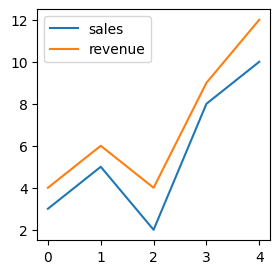

In [50]:
import pandas as pd
df = pd.DataFrame({
    'sales' : [3, 5, 2, 8, 10],
    'revenue' : [4, 6, 4, 9, 12]
})

df.plot(figsize=(3, 3))

<Axes: xlabel='sales', ylabel='revenue'>

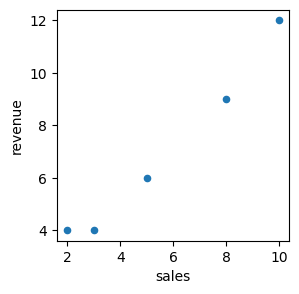

In [51]:
df.plot(kind='scatter', x='sales', y='revenue', figsize=(3, 3))

##### 3-7. 결측치, 중복치 처리

In [52]:
sample_df = pd.read_csv('./data/sample_data.csv')
sample_df

,Name,Age,Gender,City
0,Alice,24.0,F,New York
1,Bob,NaN,M,Los Angeles
2,Charlie,22.0,M,NaN
3,David,29.0,M,Chicago
4,Edward,NaN,M,Houston
5,Alice,24.0,F,New York
6,Susan,32.0,F,Houston


In [53]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    7 non-null      object 
 1   Age     5 non-null      float64
 2   Gender  7 non-null      object 
 3   City    6 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [54]:
# 컬럼별 결측치 확인
sample_df.isnull().sum()

Name      0
Age       2
Gender    0
City      1
dtype: int64

In [55]:
# 행별 결측치 확인
sample_df.isnull().any(axis=1)

0    False
1     True
2     True
3    False
4     True
5    False
6    False
dtype: bool

In [56]:
# 결측치가 있는 행 추출
sample_df[sample_df.isnull().any(axis=1)]

,Name,Age,Gender,City
1,Bob,NaN,M,Los Angeles
2,Charlie,22.0,M,NaN
4,Edward,NaN,M,Houston


In [57]:
sample_df.dropna(subset=['City'], inplace=True)
sample_df

,Name,Age,Gender,City
0,Alice,24.0,F,New York
1,Bob,NaN,M,Los Angeles
3,David,29.0,M,Chicago
4,Edward,NaN,M,Houston
5,Alice,24.0,F,New York
6,Susan,32.0,F,Houston


In [58]:
sample_df.duplicated()

0    False
1    False
3    False
4    False
5     True
6    False
dtype: bool

In [59]:
sample_df[sample_df.duplicated(keep=False)]

,Name,Age,Gender,City
0,Alice,24.0,F,New York
5,Alice,24.0,F,New York


In [60]:
sample_df

,Name,Age,Gender,City
0,Alice,24.0,F,New York
1,Bob,NaN,M,Los Angeles
3,David,29.0,M,Chicago
4,Edward,NaN,M,Houston
5,Alice,24.0,F,New York
6,Susan,32.0,F,Houston


In [61]:
sample_df.drop_duplicates(subset=['City'])

,Name,Age,Gender,City
0,Alice,24.0,F,New York
1,Bob,NaN,M,Los Angeles
3,David,29.0,M,Chicago
4,Edward,NaN,M,Houston
